# SECOM Yield Prediction — Baseline Model

**Date:** August 29, 2026
**Depends on:** 02_preprocessing.ipynb (processed data in data/processed/)

## Purpose

Establish a performance baseline using logistic regression before
attempting more complex models. The baseline defines the minimum
acceptable performance threshold for all subsequent models.

## Research question for this notebook

Can a linear model trained on preprocessed SECOM features predict
wafer failure with meaningful recall on the minority class?

## Evaluation framework

Primary metric: PR-AUC (Precision-Recall Area Under Curve)  
Secondary metrics: Recall on failure class, F1 score, ROC-AUC  
Rejected metric: Accuracy — misleading for 6.64% failure rate (documented in Day 2)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    ConfusionMatrixDisplay
)
PROCESSED = Path('../data/processed')
FIGURES = Path('../reports/figures')

X_train = pd.read_csv(PROCESSED / 'X_train.csv')
X_test = pd.read_csv(PROCESSED / 'X_test.csv')
y_train = pd.read_csv(PROCESSED / 'y_train.csv').squeeze()
y_test = pd.read_csv(PROCESSED / 'y_test.csv').squeeze()

print(f"Train: {X_train.shape} | Failures: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Test: {X_test.shape} | Failures: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

Train: (1253, 446) | Failures: 83 (6.62%)
Test: (314, 446) | Failures: 21 (6.69%)


## Scaling Applied Here, Not in Preprocessing

Scaling is applied here rather than in the preprocessing notebook
to prevent data leakage. The scaler is fit only on X_train and
applied to both X_train and X_test. If we had fit the scaler on
all data before splitting, the test set would have influenced the
scaling parameters — a form of information leakage that artificially
inflates performance estimates.


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # transform only — do not fit

joblib.dump(scaler, PROCESSED / 'scaler.pkl')
print("Scaler fit on training data only. Saved to data/processed/scaler.pkl")

Scaler fit on training data only. Saved to data/processed/scaler.pkl


## Naive Baseline: Always Predict Pass

Before training any model, we establish what a completely naive
predictor achieves. This gives our logistic regression something
to beat that is more demanding than zero. If logistic regression
cannot substantially beat this on recall, it has no practical value
for semiconductor yield prediction.


In [5]:
# Naive classifier: always predict the majority class (pass = 0)
y_naive = np.zeros(len(y_test), dtype=int)

naive_accuracy = (y_naive == y_test).mean()
naive_recall   = 0.0  # catches zero failures by definition
naive_precision = 0.0  # undefined for all-negative; set to 0

print("=== Naive Baseline (always predict PASS) ===")
print(f"Accuracy:  {naive_accuracy*100:.2f}%")
print(f"Recall on failures: {naive_recall*100:.2f}%")
print(f"Failures caught: 0 out of {y_test.sum()}")
print()
print("This is the floor. Any model that does not substantially")
print("beat this on recall has no practical value.")

=== Naive Baseline (always predict PASS) ===
Accuracy:  93.31%
Recall on failures: 0.00%
Failures caught: 0 out of 21

This is the floor. Any model that does not substantially
beat this on recall has no practical value.


## Logistic Regression Baseline

**Model choice justification:** Logistic regression is the standard
baseline for binary classification. Its coefficients directly indicate
feature influence direction and magnitude — making it interpretable
in a way that XGBoost is not by default. Outputs are genuine
probabilities, enabling threshold analysis.

**Class weight:** We set class_weight='balanced' to compensate for
the 6.64% failure rate. This internally weights failures approximately
15x higher than passes during training, forcing the model to pay
attention to the minority class rather than optimizing for the majority.

**Alternative rejected:** Without class weighting, logistic regression
optimizes for the majority class and achieves near-zero recall on
failures — practically identical to the naive baseline and useless
for yield prediction.

**Tradeoff accepted:** Balanced weighting may reduce precision —
the model will flag more false alarms to catch more true failures.
This is acceptable given the asymmetric cost structure of semiconductor
manufacturing.


In [6]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    C=1.0           # Inverse of regularization strength
)

lr_model.fit(X_train_scaled, y_train)
print("Logistic regression trained.")
print(f"Converged: {lr_model.n_iter_[0]} iterations")

Logistic regression trained.
Converged: 83 iterations


In [7]:
# Predicted probabilities — we use these for threshold-sensitive metrics
y_prob_train = lr_model.predict_proba(X_train_scaled)[:, 1]
y_prob_test  = lr_model.predict_proba(X_test_scaled)[:, 1]

# Predicted classes at default 0.5 threshold
y_pred_test  = lr_model.predict(X_test_scaled)

print("=== Logistic Regression — Test Set Performance ===\n")
print(classification_report(y_test, y_pred_test,target_names=['Pass (0)', 'Fail (1)'],digits=3))

=== Logistic Regression — Test Set Performance ===

              precision    recall  f1-score   support

    Pass (0)      0.938     0.884     0.910       293
    Fail (1)      0.105     0.190     0.136        21

    accuracy                          0.838       314
   macro avg      0.522     0.537     0.523       314
weighted avg      0.883     0.838     0.859       314



In [8]:
pr_auc  = average_precision_score(y_test, y_prob_test)
roc_auc = roc_auc_score(y_test, y_prob_test)

print(f"PR-AUC  (primary):   {pr_auc:.4f}")
print(f"ROC-AUC (secondary): {roc_auc:.4f}")
print()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(f"  True Negatives  (correct pass):   {cm[0,0]}")
print(f"  False Positives (pass → predicted fail): {cm[0,1]}")
print(f"  False Negatives (fail → predicted pass): {cm[1,0]}  ← most costly")
print(f"  True Positives  (correct fail):   {cm[1,1]}")
print()
print(f"Failures caught: {cm[1,1]} out of {y_test.sum()} ({cm[1,1]/y_test.sum()*100:.1f}%)")

PR-AUC  (primary):   0.1497
ROC-AUC (secondary): 0.6208

Confusion Matrix:
  True Negatives  (correct pass):   259
  False Positives (pass → predicted fail): 34
  False Negatives (fail → predicted pass): 17  ← most costly
  True Positives  (correct fail):   4

Failures caught: 4 out of 21 (19.0%)


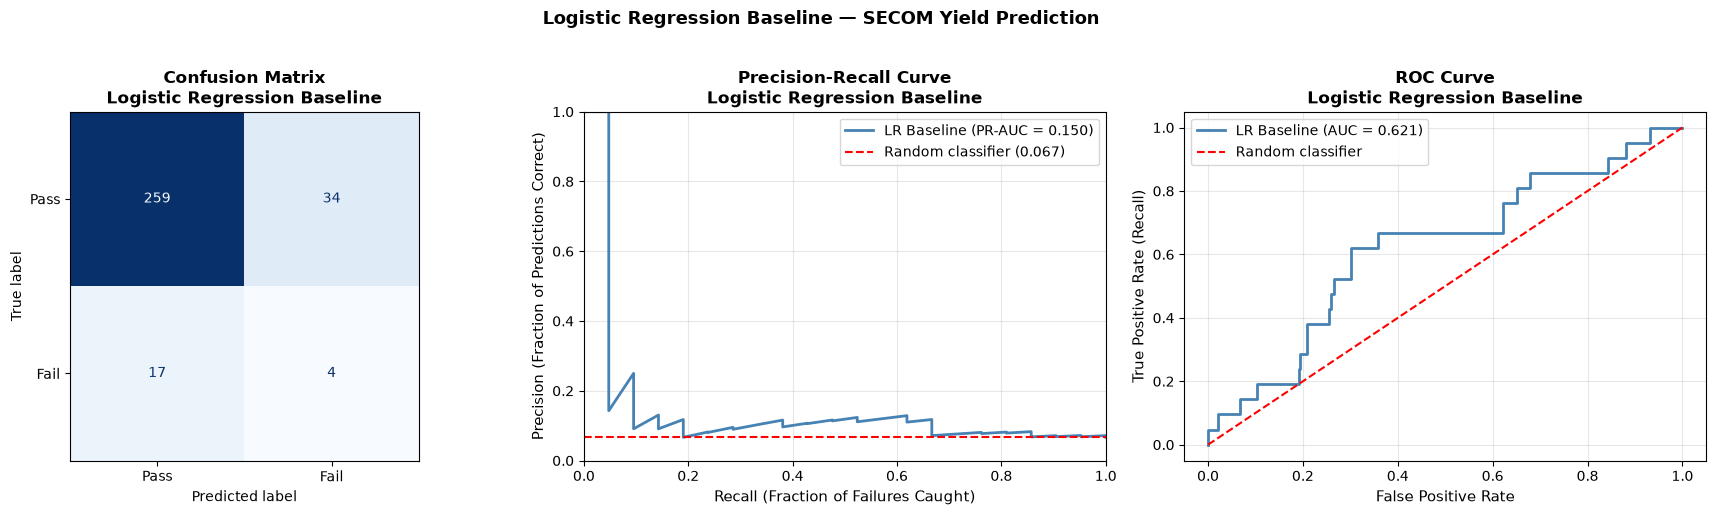

Figure saved.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Confusion Matrix ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Pass', 'Fail'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\nLogistic Regression Baseline', 
                   fontsize=12, fontweight='bold')

# --- Plot 2: Precision-Recall Curve ---
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_test)
axes[1].plot(recall, precision, color='steelblue', lw=2,
             label=f'LR Baseline (PR-AUC = {pr_auc:.3f})')
axes[1].axhline(y=y_test.mean(), color='red', linestyle='--', lw=1.5,
                label=f'Random classifier ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall (Fraction of Failures Caught)', fontsize=11)
axes[1].set_ylabel('Precision (Fraction of Predictions Correct)', fontsize=11)
axes[1].set_title('Precision-Recall Curve\nLogistic Regression Baseline',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])
axes[1].grid(alpha=0.3)

# --- Plot 3: ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[2].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'LR Baseline (AUC = {roc_auc:.3f})')
axes[2].plot([0,1], [0,1], 'r--', lw=1.5, label='Random classifier')
axes[2].set_xlabel('False Positive Rate', fontsize=11)
axes[2].set_ylabel('True Positive Rate (Recall)', fontsize=11)
axes[2].set_title('ROC Curve\nLogistic Regression Baseline',
                   fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)

plt.suptitle('Logistic Regression Baseline — SECOM Yield Prediction',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'baseline_lr_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

## Threshold Analysis

The default classification threshold of 0.5 means: predict failure
if P(failure) > 0.5. But this threshold was designed for balanced
problems. For a 6.64% failure rate, it is almost certainly wrong.

In semiconductor manufacturing, the cost of a missed failure
(false negative) is significantly higher than the cost of a false
alarm (false positive). A missed failure wastes all remaining
process steps on a doomed wafer. A false alarm wastes only the
cost of re-inspection.

This asymmetric cost structure suggests we should lower the threshold
— accepting more false alarms in exchange for catching more true failures.
The optimal threshold depends on the cost ratio, which requires fab-specific
knowledge we do not have. We explore the tradeoff explicitly.


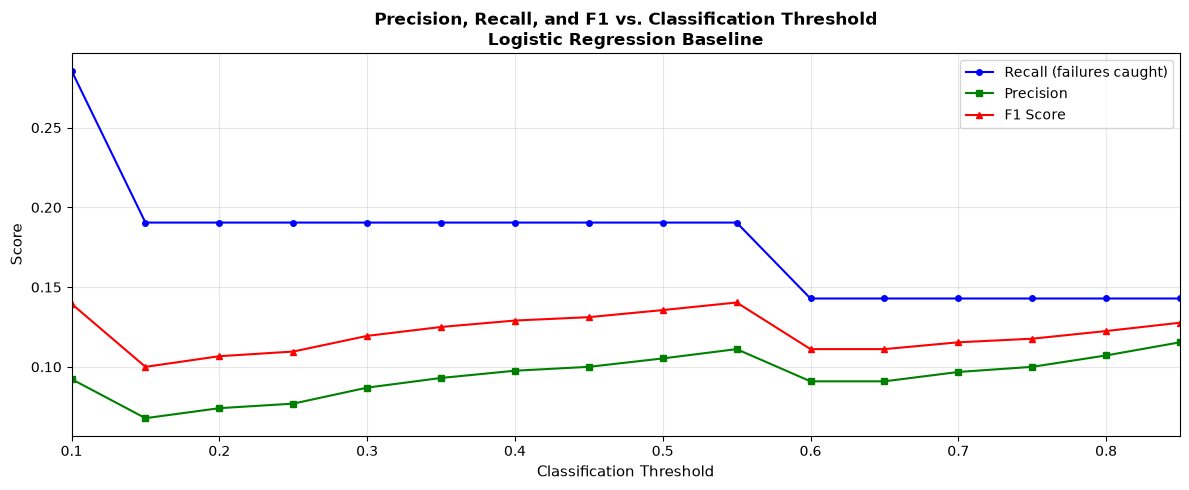


Threshold maximizing F1: 0.55
  Recall:    0.190
  Precision: 0.111
  F1:        0.140
  Failures caught: 4 of 21
  False alarms:    32


In [10]:
thresholds_to_test = np.arange(0.1, 0.9, 0.05)
results = []

for thresh in thresholds_to_test:
    y_pred_t = (y_prob_test >= thresh).astype(int)
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    
    recall_t    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_t = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_t        = (2 * precision_t * recall_t / (precision_t + recall_t) if (precision_t + recall_t) > 0 else 0)
    
    results.append({
        'threshold': thresh,
        'recall': recall_t,
        'precision': precision_t,
        'f1': f1_t,
        'failures_caught': tp,
        'false_alarms': fp
    })

results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_df['threshold'], results_df['recall'],
        'b-o', markersize=4, label='Recall (failures caught)')
ax.plot(results_df['threshold'], results_df['precision'],
        'g-s', markersize=4, label='Precision')
ax.plot(results_df['threshold'], results_df['f1'],
        'r-^', markersize=4, label='F1 Score')
ax.set_xlabel('Classification Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision, Recall, and F1 vs. Classification Threshold\nLogistic Regression Baseline',fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0.1, 0.85])

plt.tight_layout()
plt.savefig(FIGURES / 'baseline_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the row that maximizes F1
best_f1_row = results_df.loc[results_df['f1'].idxmax()]
print(f"\nThreshold maximizing F1: {best_f1_row['threshold']:.2f}")
print(f"  Recall:    {best_f1_row['recall']:.3f}")
print(f"  Precision: {best_f1_row['precision']:.3f}")
print(f"  F1:        {best_f1_row['f1']:.3f}")
print(f"  Failures caught: {int(best_f1_row['failures_caught'])} of {y_test.sum()}")
print(f"  False alarms:    {int(best_f1_row['false_alarms'])}")

In [11]:
print("\nFull threshold analysis:")
print(results_df.to_string(index=False))
results_df.to_csv(PROCESSED / 'baseline_threshold_analysis.csv', index=False)


Full threshold analysis:
 threshold   recall  precision       f1  failures_caught  false_alarms
      0.10 0.285714   0.092308 0.139535                6            59
      0.15 0.190476   0.067797 0.100000                4            55
      0.20 0.190476   0.074074 0.106667                4            50
      0.25 0.190476   0.076923 0.109589                4            48
      0.30 0.190476   0.086957 0.119403                4            42
      0.35 0.190476   0.093023 0.125000                4            39
      0.40 0.190476   0.097561 0.129032                4            37
      0.45 0.190476   0.100000 0.131148                4            36
      0.50 0.190476   0.105263 0.135593                4            34
      0.55 0.190476   0.111111 0.140351                4            32
      0.60 0.142857   0.090909 0.111111                3            30
      0.65 0.142857   0.090909 0.111111                3            30
      0.70 0.142857   0.096774 0.115385            